In [47]:
from plots import plot_policy_convergence, plot_final_policies, plot_final_policies_linear, plot_specific_state_policy, plot_specific_state_policy_linear
import pickle

In [48]:
from matplotlib import pyplot as plt
import numpy as np
import copy
from pathlib import Path

In [49]:
import os
os.getcwd()

'/Users/mathis/Documents/EPFL/Master_Thesis/CARMA-Congestion_Railway/0-Simulation'

In [50]:
path = "results/"

with open(path + 'groups.pkl', 'rb') as f:
    groups = pickle.load(f)

with open(path + 'error_vec.pkl', 'rb') as f:
    error_vec = pickle.load(f)

with open(path + 'simulation_params.pkl', 'rb') as f:
    n_day, n_groups, K, n_travelers = pickle.load(f)

with open(path + 'system.pkl', 'rb') as f:
    system = pickle.load(f)

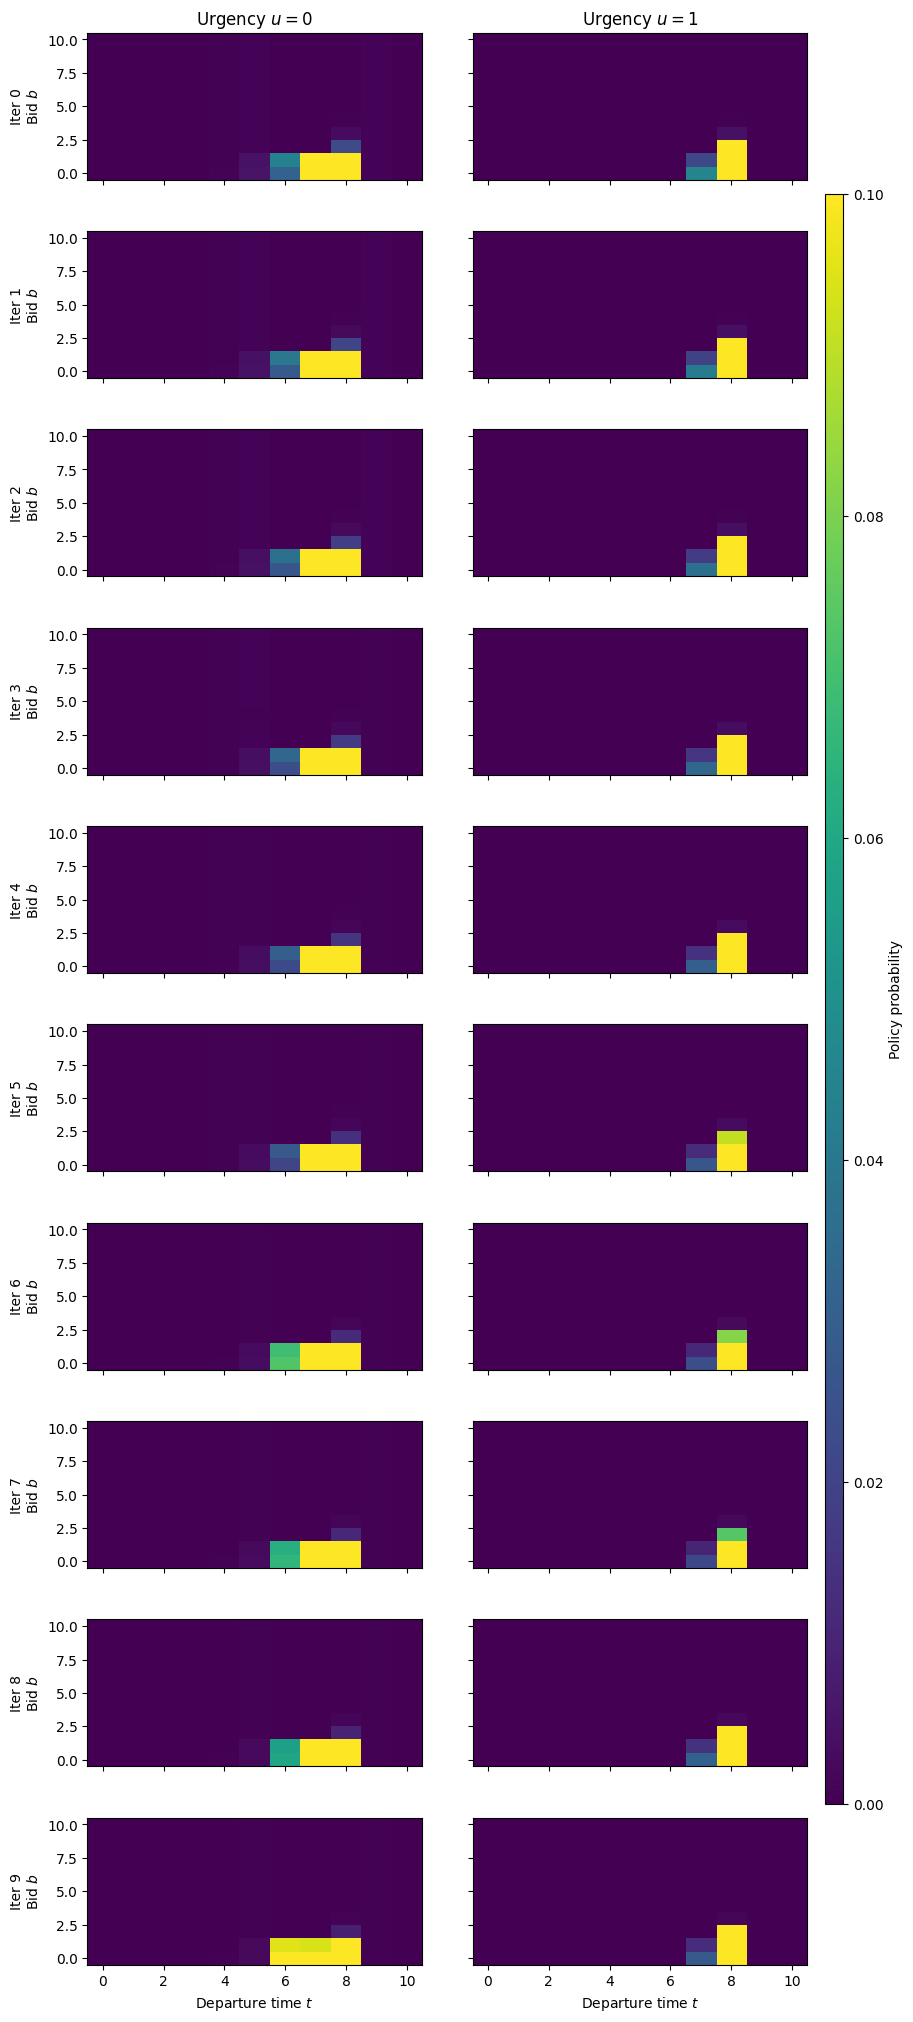

In [79]:
import matplotlib.pyplot as plt
import numpy as np

n_iter = 10
u_values = [0, 1]
k = 10
T = groups[0].T

fig, axes = plt.subplots(
    n_iter, 2,
    figsize=(9, 2.3 * n_iter),
    sharex=True, sharey=True
)

for it in range(n_iter):

    # ---- Store policy BEFORE update ----
    pi_before = {}
    for u in u_values:
        idx = u * (K + 1) + k
        pi_before[u] = groups[0].pi[idx].reshape(T, K+1).T

    # ---- One-day simulation ----
    travelers = groups[0].travelers

    # 1. Travelers act
    for tr in travelers:
        tr.store_start_state()
        tr.action()

    # 2. System queues
    system.simulate_class_attribution()

    # 3. Payment
    for tr in travelers:
        tr.paid_karma_bid()

    # 4. Redistribution
    system.karma_redistribution()

    # 5. Update urgency
    for tr in travelers:
        tr.update_urgency()

    # 6. Update each group (independent policies)
    for g in groups:
        g.update_policy(system)
        g.update_transition_matrix()


    # ---- Plot ----
    for col, u in enumerate(u_values):
        ax = axes[it, col]

        im = ax.imshow(
            pi_before[u][:11],
            origin="lower",
            aspect="auto",
            vmin=0,
            vmax=0.1
        )

        if it == 0:
            ax.set_title(f"Urgency $u={u}$")

        if col == 0:
            ax.set_ylabel(f"Iter {it}\nBid $b$")

        if it == n_iter - 1:
            ax.set_xlabel("Departure time $t$")

# ---- Manual layout control ----
plt.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.92,
    bottom=0.08,
    hspace=0.35,
    wspace=0.15
)

# ---- Dedicated colorbar axis ----
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Policy probability")

plt.show()


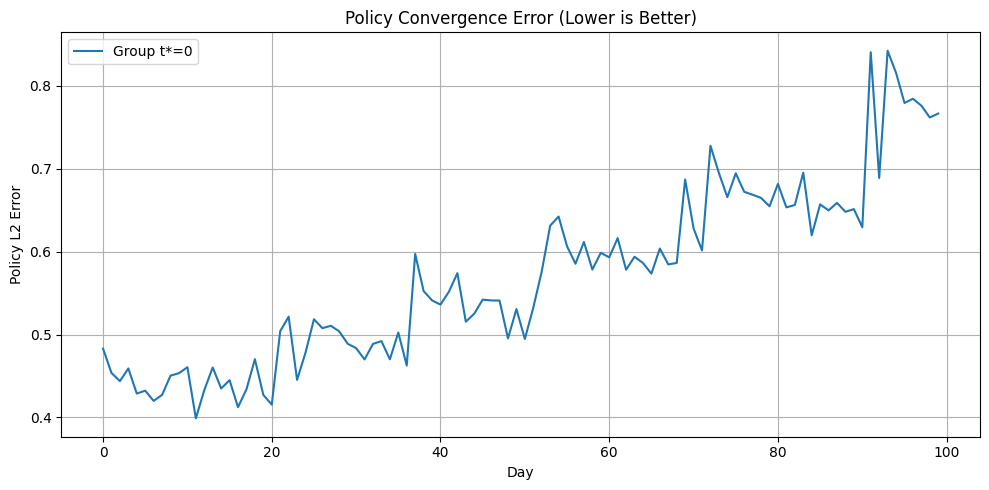

In [52]:
plot_policy_convergence(error_vec, n_day, n_groups)

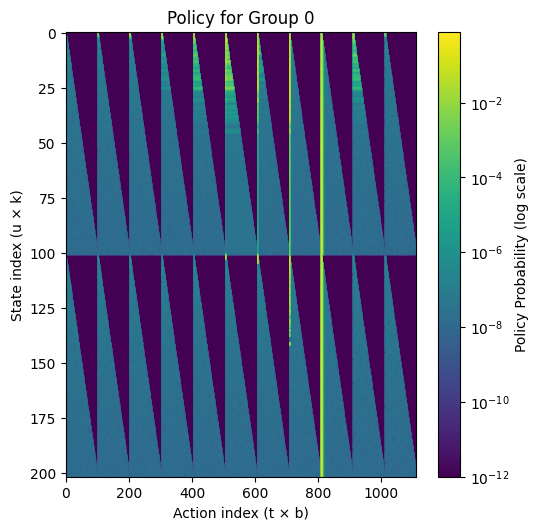

In [53]:
plot_final_policies(groups, n_groups)

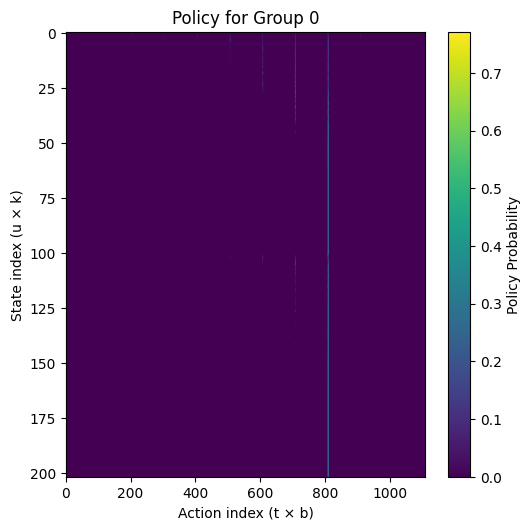

In [54]:
plot_final_policies_linear(groups, n_groups)

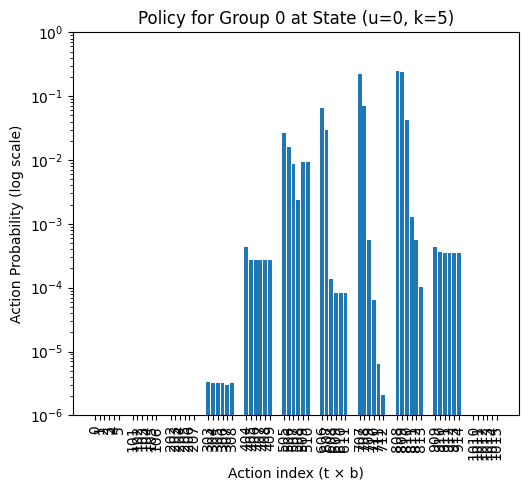

In [76]:
specific_u = 0
specific_k = 5

plot_specific_state_policy(groups, n_groups, K, specific_u, specific_k)

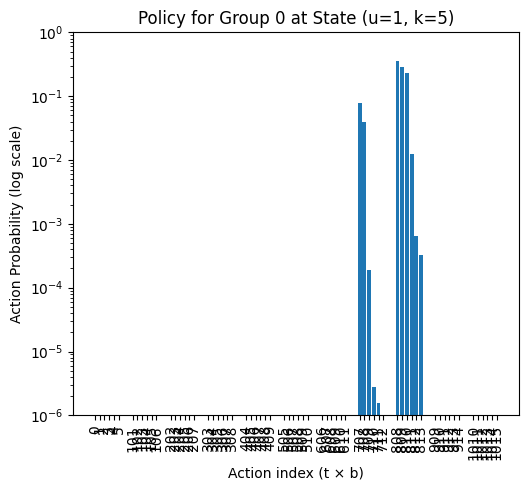

In [77]:
specific_u = 1
plot_specific_state_policy(groups, n_groups, K, specific_u, specific_k)